Load Data

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv("../data/processed/callhome_tabular_clean.csv")

print(df.shape)
df.info()
df.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 36068 entries, 0 to 36067
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   file_id          36068 non-null  int64  
 1   turn_index       36068 non-null  int64  
 2   speaker_raw      36068 non-null  str    
 3   text             36068 non-null  str    
 4   start_ms         36051 non-null  float64
 5   end_ms           36051 non-null  float64
 6   speaker_encoded  36068 non-null  int64  
 7   word_count       36068 non-null  int64  
dtypes: float64(2), int64(4), str(2)
memory usage: 2.2 MB


,file_id,turn_index,speaker_raw,text,start_ms,end_ms,speaker_encoded,word_count
0,638,0,A,right .,200460.0,200690.0,0,2
1,638,1,B,and i .,201140.0,201610.0,1,3
2,638,2,B,i already got another apartment .,201950.0,203290.0,1,6
3,638,3,B,for when i move out .,203880.0,204930.0,1,6
4,638,4,A,oh you did .,205210.0,205610.0,0,4
5,638,5,B,yeah .,205780.0,206050.0,1,2
6,638,6,A,where ?,206410.0,206720.0,0,2
7,638,7,B,it's on the corner of columbia and cole .,206830.0,209640.0,1,9
8,638,8,A,uhhuh .,210130.0,210500.0,0,2
9,638,9,B,and it's a one bedroom and .,210850.0,212500.0,1,7


# Compute Turn Duration (seconds)

In [8]:
df["turn_duration"] = (df["end_ms"] - df["start_ms"]) / 1000.0

# Turn Distribution Analysis

In [9]:
df[['word_count', 'start_ms', 'end_ms']].describe()

print("Turn distribution by speaker:")
df['speaker_raw'].value_counts(normalize=True)

Turn distribution by speaker:


speaker_raw
A    0.503244
B    0.496756
Name: proportion, dtype: float64

# Visuals
## 1.0 Examine sentence length distribution (histogram) alongside spoken word duration per turn using turn_duration (box plot)

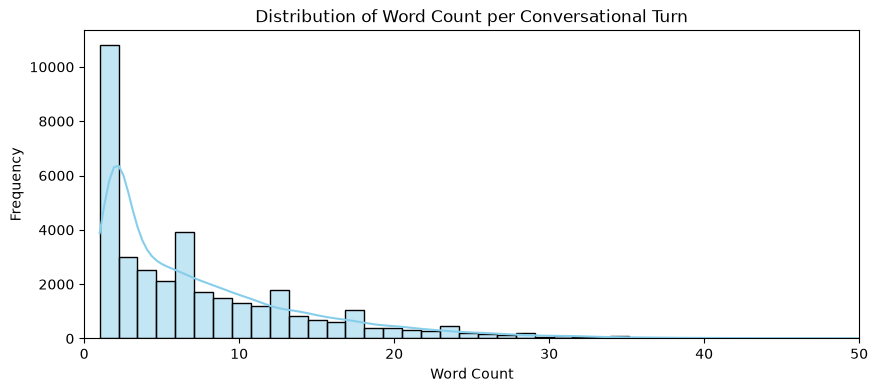

In [10]:
plt.figure(figsize=(10, 4))
sns.histplot(df['word_count'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Word Count per Conversational Turn')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.xlim(0, 50)  # Zoom in on main distribution
plt.show()

## 1.1 Speaker Interactions & Timing
### speaker_raw vs word_count (box)
### time_duration vs word_count (scatter)



C:\Users\jarre\AppData\Local\Temp\ipykernel_8044\4125651221.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


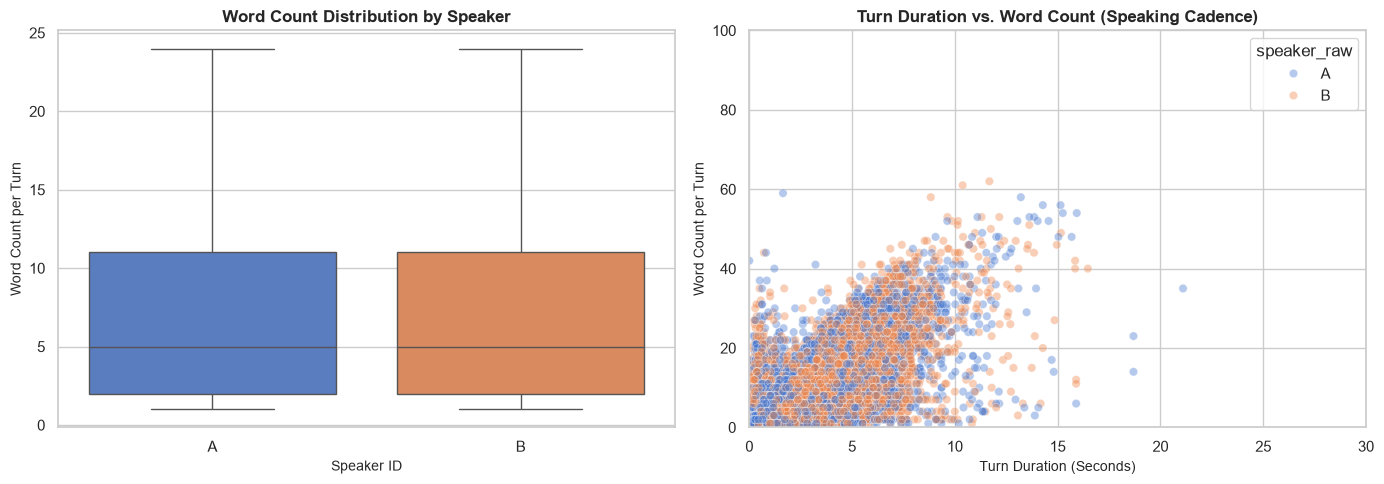

📊 Summary Metrics by Speaker:
            word_count              turn_duration             
                  mean median   std          mean median   std
speaker_raw                                                   
A                 7.75    5.0  7.06          2.03   1.41  1.91
B                 7.59    5.0  7.19          2.05   1.41  1.93

🗣️ Average Speaking Speed (Words per Second):
             Avg Words/Sec
speaker_raw               
A                     9.88
B                     8.32


In [15]:
# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 1. Word Count by Speaker (Box Plot / Violin Plot) ---
sns.boxplot(
    data=df,
    x="speaker_raw",
    y="word_count",
    palette="muted",
    ax=axes[0],
    showfliers=False,  # Hide extreme outliers for a clearer distribution view
)
axes[0].set_title("Word Count Distribution by Speaker", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Speaker ID", fontsize=10)
axes[0].set_ylabel("Word Count per Turn", fontsize=10)

# --- 2. Turn Duration vs. Word Count (Scatter Plot / Cadence) ---
# Filter out 0 duration turns to avoid divide-by-zero
valid_turns = df[df["turn_duration"] > 0].copy()

sns.scatterplot(
    data=valid_turns,
    x="turn_duration",
    y="word_count",
    hue="speaker_raw",
    alpha=0.4,
    palette="muted",
    ax=axes[1],
)
axes[1].set_title(
    "Turn Duration vs. Word Count (Speaking Cadence)",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_xlabel("Turn Duration (Seconds)", fontsize=10)
axes[1].set_ylabel("Word Count per Turn", fontsize=10)
axes[1].set_xlim(0, 30)  # Zoom in on main distribution (0-30s)
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

# --- Summary Statistics by Speaker ---
print("📊 Summary Metrics by Speaker:")
speaker_stats = (
    df.groupby("speaker_raw")[["word_count", "turn_duration"]]
    .agg(["mean", "median", "std"])
    .round(2)
)
print(speaker_stats)

# Calculate Speaking Rate (Words per Second)
valid_turns["words_per_sec"] = valid_turns["word_count"] / valid_turns["turn_duration"]
print("\n🗣️ Average Speaking Speed (Words per Second):")
print(
    valid_turns.groupby("speaker_raw")["words_per_sec"]
    .mean()
    .round(2)
    .to_frame(name="Avg Words/Sec")
)

# Response Latency Calculation
### Calculate time gap between speaker turns within each conversaion

In [17]:
# 1. Calculate latency between alternating turns within the same conversation
df["prev_speaker"] = df.groupby("file_id")["speaker_raw"].shift(1)
df["prev_end_ms"] = df.groupby("file_id")["end_ms"].shift(1)

# Calculate latency in milliseconds
df["response_latency_ms"] = np.where(
    (df["speaker_raw"] != df["prev_speaker"]) & (df["prev_speaker"].notna()),
    df["start_ms"] - df["prev_end_ms"],
    np.nan,
)

# Convert to seconds
df["response_latency_s"] = df["response_latency_ms"] / 1000.0

# 2. Display Overview / Summary Statistics
valid_latencies = df["response_latency_s"].dropna()

print("=" * 55)
print("⏱️ RESPONSE LATENCY OVERVIEW")
print("=" * 55)
print(f"Total Alternating Speaker Turns Measured : {len(valid_latencies):,}")
print(
    f"Missing / Same-Speaker Turns Ignored  : {df['response_latency_s'].isna().sum():,}\n"
)

print("--- Summary Statistics (in Seconds) ---")
stats = valid_latencies.describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]).round(3)
print(stats)

print("\n--- Behavioral Latency Breakdown ---")
overlaps = (valid_latencies < 0).sum()
fast_replies = ((valid_latencies >= 0) & (valid_latencies <= 1.0)).sum()
standard_replies = ((valid_latencies > 1.0) & (valid_latencies <= 3.0)).sum()
long_pauses = (valid_latencies > 3.0).sum()

total = len(valid_latencies)
print(
    f"Overlaps / Interruptions (< 0s)      : {overlaps:>6,} ({overlaps / total * 100:.1f}%)"
)
print(
    f"Fast Responses (0s - 1s)            : {fast_replies:>6,} ({fast_replies / total * 100:.1f}%)"
)
print(
    f"Standard Responses (1s - 3s)        : {standard_replies:>6,} ({standard_replies / total * 100:.1f}%)"
)
print(
    f"Long Pauses / Gaps (> 3s)           : {long_pauses:>6,} ({long_pauses / total * 100:.1f}%)\n"
)

print("--- Sample Table Preview ---")
preview_cols = [
    "file_id",
    "turn_index",
    "speaker_raw",
    "start_ms",
    "end_ms",
    "response_latency_s",
]
print(df[preview_cols].dropna(subset=["response_latency_s"]).head(5))
print("=" * 55)

⏱️ RESPONSE LATENCY OVERVIEW
Total Alternating Speaker Turns Measured : 23,262
Missing / Same-Speaker Turns Ignored  : 12,806

--- Summary Statistics (in Seconds) ---
count    23262.000
mean        -0.282
std          1.286
min        -15.900
5%          -2.560
25%         -0.530
50%         -0.080
75%          0.290
95%          1.040
max         28.990
Name: response_latency_s, dtype: float64

--- Behavioral Latency Breakdown ---
Overlaps / Interruptions (< 0s)      : 12,893 (55.4%)
Fast Responses (0s - 1s)            :  9,147 (39.3%)
Standard Responses (1s - 3s)        :  1,085 (4.7%)
Long Pauses / Gaps (> 3s)           :    137 (0.6%)

--- Sample Table Preview ---
   file_id  turn_index speaker_raw  start_ms    end_ms  response_latency_s
1      638           1           B  201140.0  201610.0                0.45
4      638           4           A  205210.0  205610.0                0.28
5      638           5           B  205780.0  206050.0                0.17
6      638           6 

# Outlier Detection

In [19]:
import numpy as np
import pandas as pd

# 1. Calculate Interquartile Range (IQR) for Response Latency (in milliseconds)
Q1 = df["response_latency_ms"].quantile(0.25)
Q3 = df["response_latency_ms"].quantile(0.75)
IQR = Q3 - Q1

# Define upper and lower outlier thresholds
upper_bound_ms = Q3 + 1.5 * IQR
lower_bound_ms = Q1 - 1.5 * IQR  # Often captures significant speech overlaps

# 2. Extract Outlier Subsets
upper_outliers = df[df["response_latency_ms"] > upper_bound_ms]
lower_outliers = df[df["response_latency_ms"] < lower_bound_ms]
total_valid_turns = df["response_latency_ms"].dropna().shape[0]

# 3. Print Outlier Overview Summary
print("=" * 60)
print("🔍 RESPONSE LATENCY OUTLIER ANALYSIS (IQR METHOD)")
print("=" * 60)
print(f"25th Percentile (Q1)          : {Q1 / 1000:.2f}s ({Q1:.0f} ms)")
print(f"75th Percentile (Q3)          : {Q3 / 1000:.2f}s ({Q3:.0f} ms)")
print(f"Interquartile Range (IQR)     : {IQR / 1000:.2f}s ({IQR:.0f} ms)")
print("-" * 60)
print(
    f"Upper Outlier Threshold (> Q3+1.5*IQR) : {upper_bound_ms / 1000:.2f}s ({upper_bound_ms:.0f} ms)"
)
print(
    f"Lower Outlier Threshold (< Q1-1.5*IQR) : {lower_bound_ms / 1000:.2f}s ({lower_bound_ms:.0f} ms)"
)
print("=" * 60)

# Volume Breakdown
print("\n📊 Outlier Count & Proportions:")
print(
    f"Upper Outliers (Long Pauses / Gaps) : {len(upper_outliers):>5,} turns ({len(upper_outliers) / total_valid_turns * 100:.2f}%)"
)
print(
    f"Lower Outliers (Overlaps/Interrupts): {len(lower_outliers):>5,} turns ({len(lower_outliers) / total_valid_turns * 100:.2f}%)"
)

# 4. Outlier Statistical Summary (in Seconds)
print("\n--- Upper Outliers Distribution (Seconds) ---")
print((upper_outliers["response_latency_ms"] / 1000.0).describe().round(2))

# 5. Top 5 Longest Response Gaps (Potential Extreme Stonewalling Sequences)
print("\n--- Top 5 Extreme Response Latencies (Potential Stonewalling) ---")
cols_to_show = [
    "file_id",
    "turn_index",
    "speaker_raw",
    "response_latency_s",
    "word_count",
    "text",
]
print(
    upper_outliers.sort_values(by="response_latency_ms", ascending=False)[
        cols_to_show
    ].head(5)
)
print("=" * 60)

🔍 RESPONSE LATENCY OUTLIER ANALYSIS (IQR METHOD)
25th Percentile (Q1)          : -0.53s (-530 ms)
75th Percentile (Q3)          : 0.29s (290 ms)
Interquartile Range (IQR)     : 0.82s (820 ms)
------------------------------------------------------------
Upper Outlier Threshold (> Q3+1.5*IQR) : 1.52s (1520 ms)
Lower Outlier Threshold (< Q1-1.5*IQR) : -1.76s (-1760 ms)

📊 Outlier Count & Proportions:
Upper Outliers (Long Pauses / Gaps) :   566 turns (2.43%)
Lower Outliers (Overlaps/Interrupts): 2,021 turns (8.69%)

--- Upper Outliers Distribution (Seconds) ---
count    566.00
mean       2.67
std        1.77
min        1.53
25%        1.78
50%        2.17
75%        2.98
max       28.99
Name: response_latency_ms, dtype: float64

--- Top 5 Extreme Response Latencies (Potential Stonewalling) ---
       file_id  turn_index speaker_raw  response_latency_s  word_count  \
7210      4415         251           B               28.99           2   
10295     4580          67           A             

# Early Feature Engineering

In [ ]:
import re

import numpy as np
import pandas as pd

# Ensure text column is treated as string and handle lowercasing safely
df["text_clean"] = df["text"].fillna("").astype(str).str.lower()


# --- 1. Helper Regex Functions ---
def count_word_exact(text, word):
    """Counts exact whole word matches in text using word boundaries."""
    return len(re.findall(r"\b" + re.escape(word) + r"\b", text))


def starts_with_contrastive(text):
    """Checks if a turn begins with contrastive conjunctions 'but' or 'however'."""
    text_trimmed = text.strip()
    return int(text_trimmed.startswith("but") or text_trimmed.startswith("however"))


# --- 2. Calculate Turn-Level Metrics ---
# Count exact occurrences of pronouns
df["count_you"] = df["text_clean"].apply(lambda x: count_word_exact(x, "you"))
df["count_i"] = df["text_clean"].apply(lambda x: count_word_exact(x, "i"))

# Turn-level You-Ratio (avoid division by zero)
df["you_ratio"] = np.where(
    df["word_count"] > 0, df["count_you"] / df["word_count"], 0.0
)

# Token Collapse / Short Turn Flag (Potential Stonewalling metric)
df["is_token_collapse"] = (df["word_count"] <= 3).astype(int)

# Contrastive Start Flag (Potential Defensiveness / Criticism metric)
df["starts_contrastive"] = df["text_clean"].apply(starts_with_contrastive)


# --- 3. Output Dataset-Wide Overview ---
total_turns = len(df)
total_words = df["word_count"].sum()
total_you = df["count_you"].sum()
total_i = df["count_i"].sum()

print("=" * 60)
print("🧠 GOTTMAN LEXICAL MAPPING OVERVIEW")
print("=" * 60)

print("--- 1. Pronoun Dynamics ---")
print(f"Total 'you' count across corpus  : {total_you:,}")
print(f"Total 'i' count across corpus    : {total_i:,}")
print(
    f"Corpus You-to-I Ratio            : {(total_you / total_i):.3f}"
    if total_i > 0
    else "N/A"
)
print(f"Corpus 'you' density (per word)  : {(total_you / total_words):.4f}")
print(f"Mean Turn-Level You-Ratio        : {df['you_ratio'].mean():.4f}")

print("\n--- 2. Stonewalling Baseline (Token Collapse) ---")
collapse_count = df["is_token_collapse"].sum()
print(
    f"Short Turns (word_count <= 3)     : {collapse_count:,} / {total_turns:,} ({collapse_count / total_turns * 100:.2f}%)"
)

print("\n--- 3. Contrastive Conjunction Baseline ---")
contrastive_count = df["starts_contrastive"].sum()
print(
    f"Turns starting with 'but'/'however': {contrastive_count:,} / {total_turns:,} ({contrastive_count / total_turns * 100:.2f}%)"
)


# --- 4. Breakdown by Speaker ---
print("\n" + "=" * 60)
print("🗣️ GOTTMAN METRICS BY SPEAKER (A vs. B)")
print("=" * 60)

speaker_gottman = (
    df.groupby("speaker_raw")
    .agg(
        total_turns=("turn_index", "count"),
        avg_you_ratio=("you_ratio", "mean"),
        total_you=("count_you", "sum"),
        total_i=("count_i", "sum"),
        token_collapse_pct=(
            "is_token_collapse",
            lambda x: (x.sum() / len(x)) * 100,
        ),
        starts_contrastive_pct=(
            "starts_contrastive",
            lambda x: (x.sum() / len(x)) * 100,
        ),
    )
    .round(2)
)

# Calculate speaker-specific You-to-I ratio
speaker_gottman["you_to_i_ratio"] = (
    speaker_gottman["total_you"] / speaker_gottman["total_i"]
).round(3)

print(
    speaker_gottman[
        [
            "total_turns",
            "you_to_i_ratio",
            "avg_you_ratio",
            "token_collapse_pct",
            "starts_contrastive_pct",
        ]
    ]
)
print("=" * 60)

🧠 GOTTMAN LEXICAL MAPPING OVERVIEW
--- 1. Pronoun Dynamics ---
Total 'you' count across corpus  : 7,235
Total 'i' count across corpus    : 12,585
Corpus You-to-I Ratio            : 0.575
Corpus 'you' density (per word)  : 0.0261
Mean Turn-Level You-Ratio        : 0.0191

--- 2. Stonewalling Baseline (Token Collapse) ---
Short Turns (word_count <= 3)     : 13,789 / 36,068 (38.23%)

--- 3. Contrastive Conjunction Baseline ---
Turns starting with 'but'/'however': 1,063 / 36,068 (2.95%)

🗣️ GOTTMAN METRICS BY SPEAKER (A vs. B)
             total_turns  you_to_i_ratio  avg_you_ratio  token_collapse_pct  \
speaker_raw                                                                   
A                  18151           0.597           0.02               36.92   
B                  17917           0.552           0.02               39.55   

             starts_contrastive_pct  
speaker_raw                          
A                              3.06  
B                              2.83  


: 